# Step 1: Image Dataset Construction and Visualisation

In [1]:
pip install torch torchvision opencv-python numpy

  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_x86_64.whl (6.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install "numpy<2.0.0"

  Using cached numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl (20.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


Generating visualization comparison matrix for corrupted data...
Files already downloaded and verified
Visualization matrix generated and safely saved to: cifar10_corruptions_preview.png


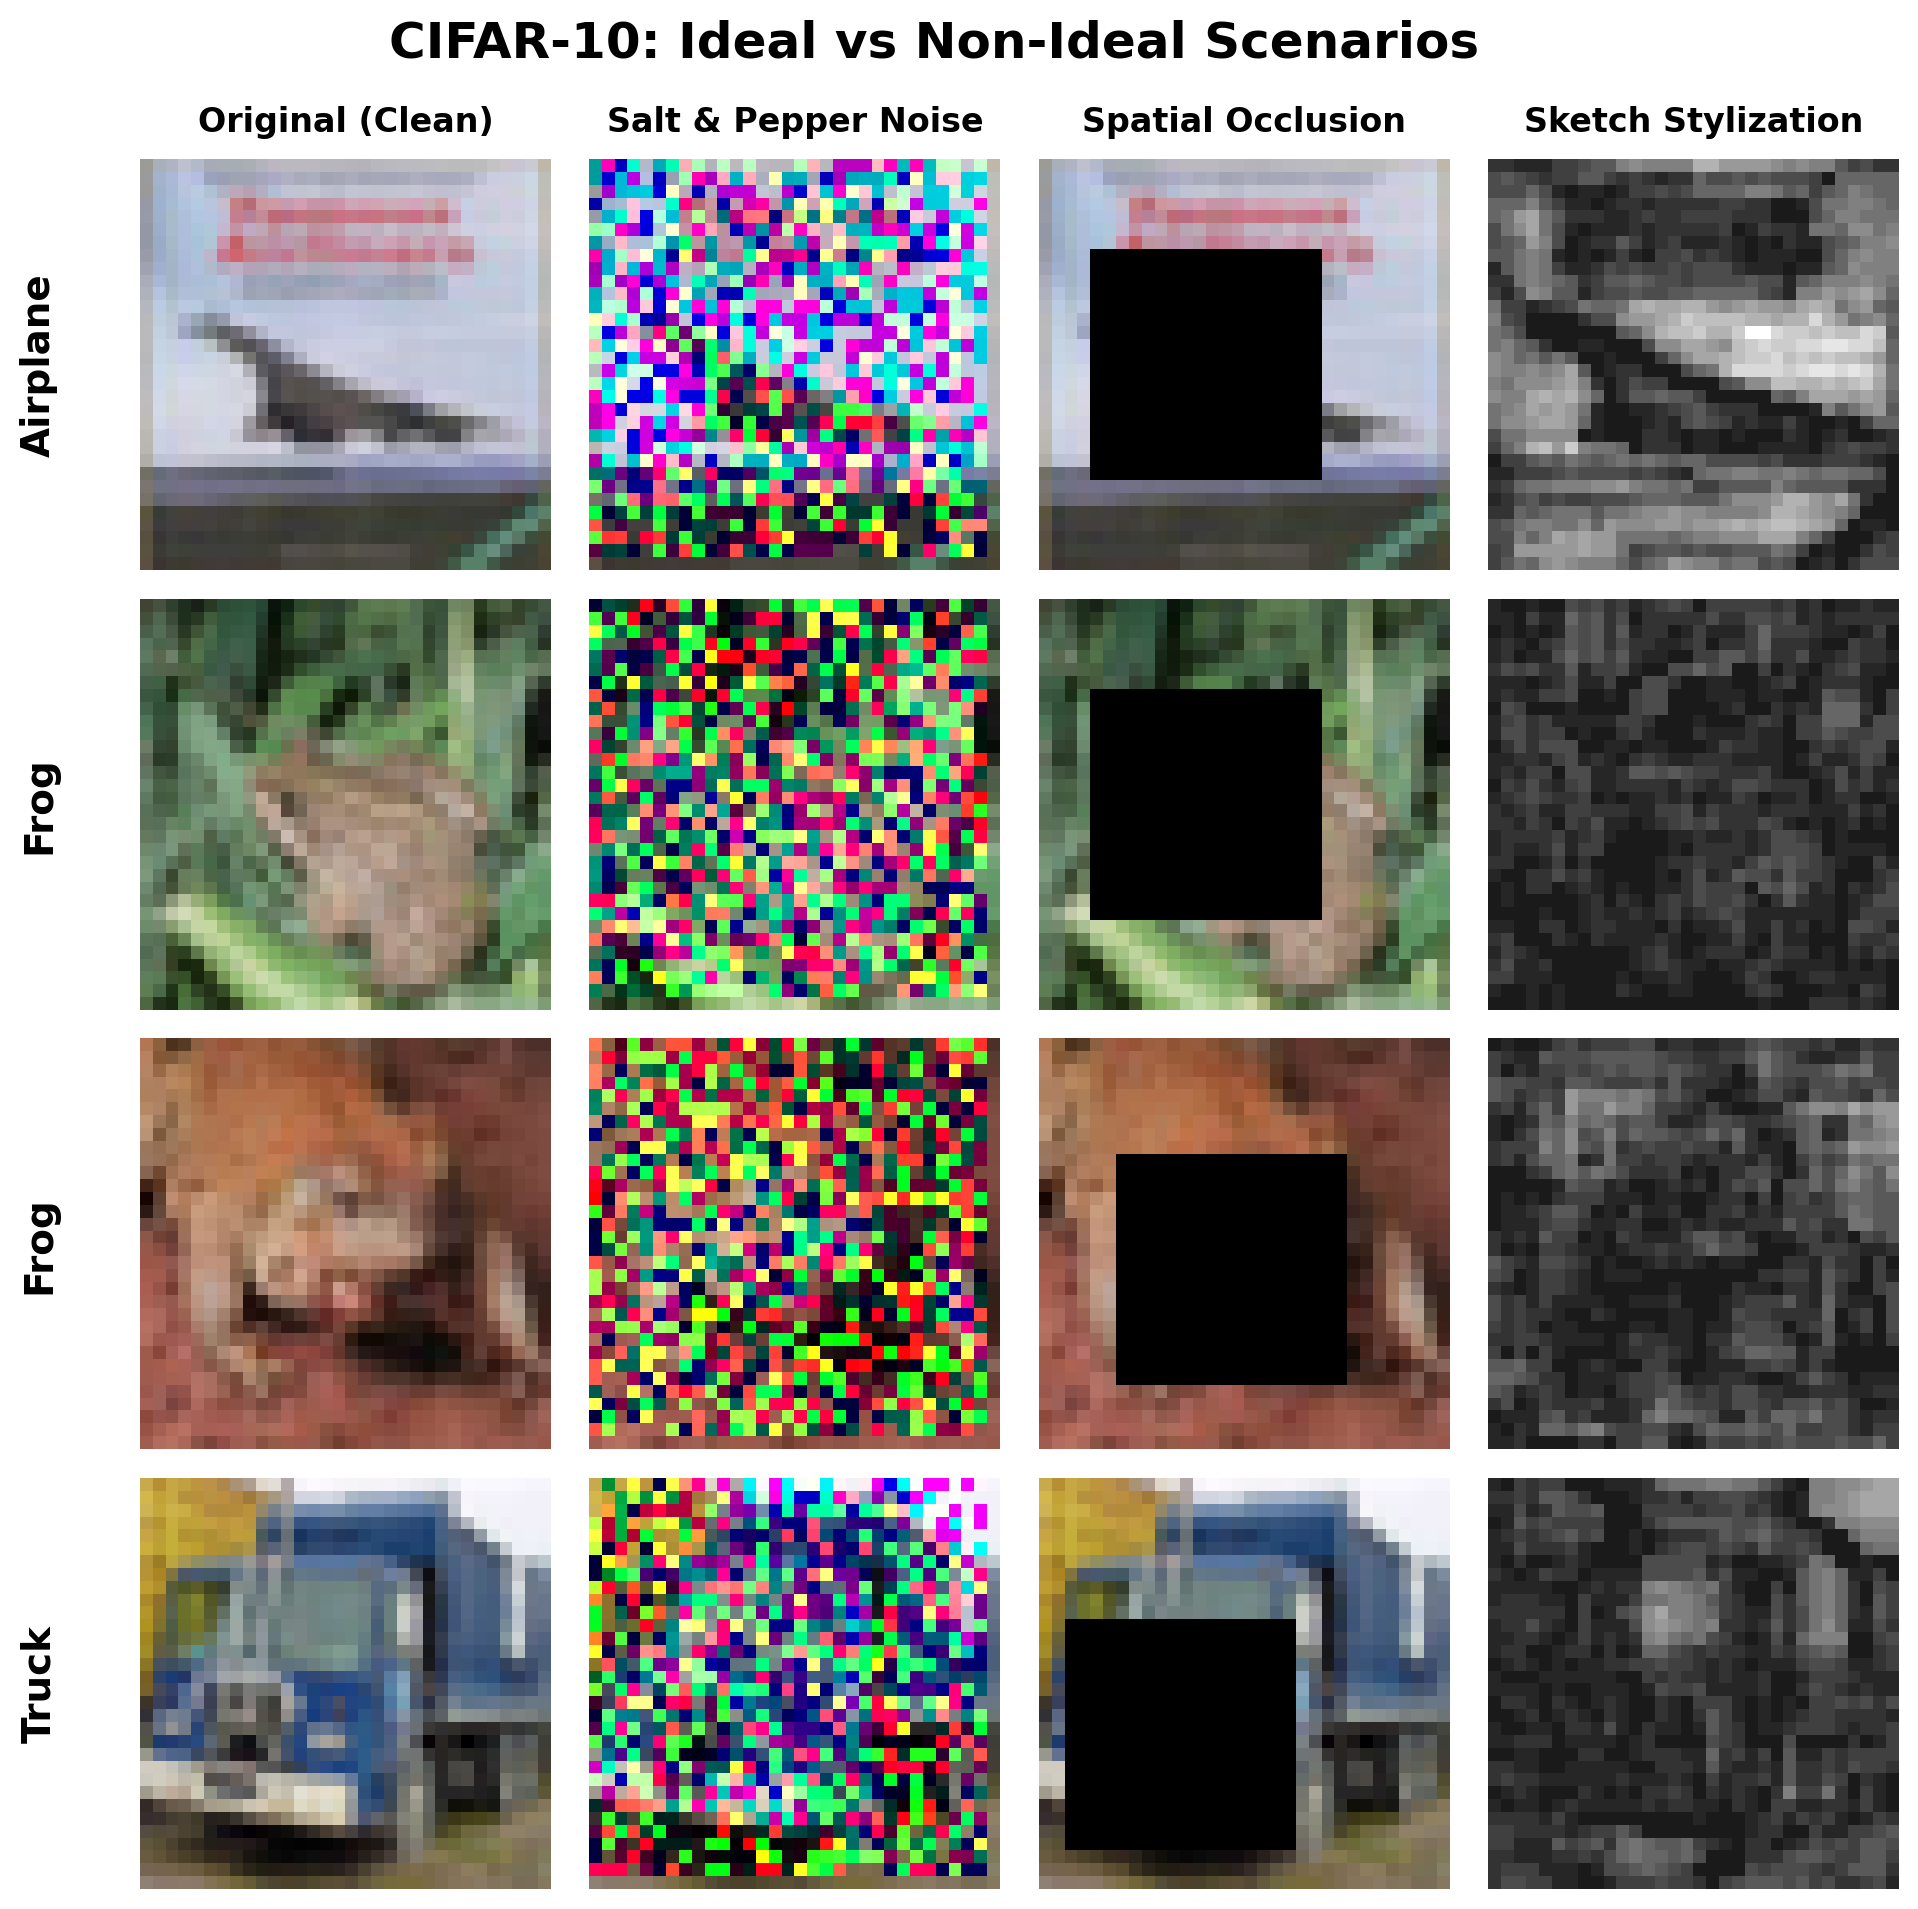


Preparing CIFAR-10 dataloaders with non-ideal scenario corruptions...
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Dataloaders ready! Includes the following test sets:
 - train          : 50000 images
 - test_clean     : 10000 images
 - test_noise     : 10000 images
 - test_occlusion : 10000 images
 - test_sketch    : 10000 images


In [6]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# ==========================================
# 1. Custom Corruption Transformations (Noise, Occlusion, Stylization)
# ==========================================

class AddSaltPepperNoise(object):
    """Add 50% Salt and Pepper Noise"""
    def __init__(self, prob=0.5):
        self.prob = prob

    def __call__(self, img):
        img_arr = np.array(img)
        row, col, ch = img_arr.shape
        s_vs_p = 0.5
        amount = self.prob
        out = np.copy(img_arr)

        # Add Salt Noise
        num_salt = np.ceil(amount * img_arr.size * s_vs_p)
        coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img_arr.shape]
        out[tuple(coords)] = 255

        # Add Pepper Noise
        num_pepper = np.ceil(amount * img_arr.size * (1. - s_vs_p))
        coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img_arr.shape]
        out[tuple(coords)] = 0

        return Image.fromarray(out)

class SketchStylization(object):
    def __call__(self, img):
        img_arr = np.array(img)
        gray_sketch, color_sketch = cv2.pencilSketch(img_arr, sigma_s=60, sigma_r=0.07, shade_factor=0.05)

        sketch_rgb = cv2.cvtColor(gray_sketch, cv2.COLOR_GRAY2RGB)

        return Image.fromarray(sketch_rgb)

# ==========================================
# 2. Data Processing Pipeline and DataLoaders
# ==========================================

def get_cifar10_dataloaders(batch_size=64):
    """Get base and corrupted CIFAR-10 dataloaders"""

    base_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    # 1. Ideal Scenario
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=base_transform)
    test_clean = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=base_transform)

    # 2. 50% Salt and Pepper Noise Scenario
    transform_noise = transforms.Compose([
        AddSaltPepperNoise(prob=0.5),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    test_noise = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_noise)

    # 3. 30% Spatial Occlusion Scenario
    transform_occlusion = transforms.Compose([
        transforms.ToTensor(),
        transforms.RandomErasing(p=1.0, scale=(0.3, 0.3), ratio=(1.0, 1.0), value=0), # Strict 30% area
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    test_occlusion = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_occlusion)

    # 4. Sketch Stylization Scenario
    transform_sketch = transforms.Compose([
        SketchStylization(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    test_sketch = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_sketch)

    dataloaders = {
        'train': torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0),
        'test_clean': torch.utils.data.DataLoader(test_clean, batch_size=batch_size, shuffle=False, num_workers=0),
        'test_noise': torch.utils.data.DataLoader(test_noise, batch_size=batch_size, shuffle=False, num_workers=0),
        'test_occlusion': torch.utils.data.DataLoader(test_occlusion, batch_size=batch_size, shuffle=False, num_workers=0),
        'test_sketch': torch.utils.data.DataLoader(test_sketch, batch_size=batch_size, shuffle=False, num_workers=0),
    }

    return dataloaders

# ==========================================
# 3. Core Visualization Module
# ==========================================
def visualize_transformations():
    print("Generating visualization comparison matrix for corrupted data...")
    
    # Get the raw dataset (no Normalize, keep displayable PIL format)
    dataset_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)
    classes = dataset_raw.classes

    noise_transform = AddSaltPepperNoise(prob=0.5)
    sketch_transform = SketchStylization()
    transform_to_tensor = transforms.ToTensor()
    erasing_transform = transforms.RandomErasing(p=1.0, scale=(0.3, 0.3), ratio=(1.0, 1.0), value=0)

    indices = [3, 4, 5, 14] 
    
    fig, axes = plt.subplots(4, 4, figsize=(10, 10), dpi=200)
    fig.suptitle('CIFAR-10: Ideal vs Non-Ideal Scenarios', fontsize=18, fontweight='bold', y=0.95)
    
    col_titles = ['Original (Clean)', 'Salt & Pepper Noise', 'Spatial Occlusion', 'Sketch Stylization']

    for i, idx in enumerate(indices):
        img_pil, label = dataset_raw[idx]

        # 1. Original Image
        img_clean = np.array(img_pil)

        # 2. Salt and Pepper Noise
        img_noise = np.array(noise_transform(img_pil))

        # 3. Occlusion (RandomErasing requires Tensor input)
        img_tensor = transform_to_tensor(img_pil)
        img_erased = erasing_transform(img_tensor)
        img_occlusion = img_erased.permute(1, 2, 0).numpy() # Convert back to (H,W,C) for display

        # 4. Sketch Stylization
        img_sketch = np.array(sketch_transform(img_pil))

        images = [img_clean, img_noise, img_occlusion, img_sketch]

        for j in range(4):
            ax = axes[i, j]
            if j == 2:
                ax.imshow(images[j])
            else:
                ax.imshow(images[j].astype(np.uint8))
                
            ax.axis('off')

            if i == 0:
                ax.set_title(col_titles[j], fontsize=12, fontweight='bold', pad=10)

            if j == 0:
                ax.text(-0.2, 0.5, classes[label].capitalize(), 
                        transform=ax.transAxes, fontsize=14, fontweight='bold', 
                        va='center', ha='right', rotation=90)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88, left=0.1)
    
    save_path = 'cifar10_corruptions_preview.png'
    plt.savefig(save_path, bbox_inches='tight', transparent=False)
    print(f"Visualization matrix generated and safely saved to: {save_path}")
    plt.show()

# ==========================================
# 4. Main Execution Entry Point
# ==========================================
if __name__ == "__main__":
    visualize_transformations()
    
    print("\n" + "="*50)
    print("Preparing CIFAR-10 dataloaders with non-ideal scenario corruptions...")
    dataloaders = get_cifar10_dataloaders(batch_size=128)
    
    print("Dataloaders ready! Includes the following test sets:")
    for key in dataloaders.keys():
        print(f" - {key.ljust(15)}: {len(dataloaders[key].dataset)} images")

# Step 2: Model Architecture Definition

In [8]:
import torch.nn as nn
from torchvision.models.vision_transformer import VisionTransformer

# ==========================================
# 0. Lightweight Model Definitions (Uniformly aligned to ~1.7 M level)
# ==========================================

# 1. Traditional MLP
class MLPMini(nn.Module):
    def __init__(self, input_dim=32*32*3, hidden_dim=512, num_classes=10):
        super(MLPMini, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),        
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),  
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

# 2. Miniature CNN 
class CNNMini(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNMini, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 768), 
            nn.ReLU(),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# 3. Miniature ViT
def get_micro_vit_model(num_classes=10):
    model = VisionTransformer(
        image_size=32,
        patch_size=4,     
        num_layers=6,       
        num_heads=6,         
        hidden_dim=192,      
        mlp_dim=384,         
        num_classes=num_classes
    )
    return model

# ==========================================
# Test and print parameter counts
# ==========================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

if __name__ == "__main__":
    print(">>> Initializing 3 lightweight deep learning architectures at the 1.7M level...\n")

    dummy_input = torch.randn(2, 3, 32, 32)

    models_dict = {
        "MLP_Mini": MLPMini(),
        "CNN_Mini": CNNMini(),
        "ViT_Micro": get_micro_vit_model()
    }

    print("=" * 65)
    print("Model Complexity & Forward Pass Test")
    print("=" * 65)
    print(f"{'Architecture':<15} | {'Params Count':<15} | {'Output Shape':<12}")
    print("-" * 65)

    for name, model in models_dict.items():
        output = model(dummy_input)
        params_count = count_parameters(model) / 1e6
        print(f"{name:<13} | {params_count:>8.2f} M        | {str(list(output.shape)):<12}")

    print("-" * 65)

>>> Initializing 3 lightweight deep learning architectures at the 1.7M level...

Model Complexity & Forward Pass Test
Architecture    | Params Count    | Output Shape
-----------------------------------------------------------------
MLP_Mini      |     1.71 M        | [2, 10]     
CNN_Mini      |     1.67 M        | [2, 10]     
ViT_Micro     |     1.81 M        | [2, 10]     
-----------------------------------------------------------------


# Step 3: Model training

In [10]:
import torch.optim as optim
from pathlib import Path
from tqdm import tqdm

class MLPMini(nn.Module):
    def __init__(self, input_dim=32*32*3, hidden_dim=512, num_classes=10):
        super(MLPMini, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),        
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),  
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    def forward(self, x):
        return self.network(self.flatten(x))

class CNNMini(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNMini, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 768),  
            nn.ReLU(),
            nn.Linear(768, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def get_micro_vit_model(num_classes=10):
    return VisionTransformer(
        image_size=32, patch_size=4, num_layers=6, num_heads=6,         
        hidden_dim=192, mlp_dim=384, num_classes=num_classes
    )

# ==========================================
# 1. Independent Training Module 
# ==========================================
def run_training_phase(models_dict, dataloaders, num_epochs=30, device='cpu', save_dir='./saved_models'):
    print(f"\n{'='*60}\n[Phase 1] Starting model training and sealing\n{'='*60}")
    base_path = Path(save_dir)
    base_path.mkdir(parents=True, exist_ok=True)
    
    for model_name, model in models_dict.items():
        safe_name = model_name.replace(" ", "_").lower()
        model_save_path = base_path / f"{safe_name}_weights.pth"
        
        if model_save_path.exists():
            print(f"\n>>> Found existing local weight file, loading [{model_name}] directly and skipping training.")
            model.load_state_dict(torch.load(str(model_save_path), map_location=device))
            model = model.to(device)
            continue  
            
        print(f"\n>>> No historical weights detected, training from scratch: [{model_name}]")
        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        
        for epoch in range(num_epochs):
            model.train()
            running_loss, correct, total = 0.0, 0, 0
            train_loop = tqdm(dataloaders['train'], desc=f"Epoch [{epoch+1}/{num_epochs}]", colour='green')
            
            for inputs, labels in train_loop:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                train_loop.set_postfix(loss=f"{loss.item():.4f}")
                
            if device.type in ['mps', 'cuda']:
                torch.cuda.empty_cache() if device.type == 'cuda' else torch.mps.empty_cache()

        torch.save(model.state_dict(), str(model_save_path))
        print(f"{model_name} training complete! Weights saved to: {model_save_path}")

# ==========================================
# Execution Logic 
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Current compute device: {device}")
    
    models_to_train = {
         "MLP_Mini": MLPMini(),
         "CNN_Mini": CNNMini(),
         "ViT_Micro": get_micro_vit_model() 
    }
    
    try:
        print("Preparing dataloaders...")
        dataloaders = get_cifar10_dataloaders(batch_size=128)
        print("Data preparation complete, ready to enter the training phase!")
        
        run_training_phase(models_to_train, dataloaders, num_epochs=30, device=device, save_dir="../saved_models")
        
    except NameError as e:
        print(f"Fatal error: Function or variable not found. Details: {e}")
        print("Hint: Please ensure the code containing the get_cifar10_dataloaders function has been run!")

Current compute device: mps
Preparing dataloaders...
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Data preparation complete, ready to enter the training phase!

[Phase 1] Starting model training and sealing

>>> Found existing local weight file, loading [MLP_Mini] directly and skipping training.

>>> Found existing local weight file, loading [CNN_Mini] directly and skipping training.

>>> Found existing local weight file, loading [ViT_Micro] directly and skipping training.


# Step 4: Model Predictions and Comparisons

In [11]:
import torch.nn.functional as F
import time
import json
from pathlib import Path
from sklearn.metrics import f1_score
import numpy as np

def calculate_ece(probs, labels, n_bins=10):

    confidences = np.max(probs, axis=1) 
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels) 

    ece = 0.0
    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i+1]

        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin) 
        
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin]) 
            avg_confidence_in_bin = np.mean(confidences[in_bin]) 
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece * 100 

def run_evaluation_phase(models_dict, dataloaders, device='cpu', weights_dir='./saved_models', output_json='evaluation_results.json'):
    print(f"\n{'='*65}")
    print(f"[Phase 2] Starting cross-scenario multi-dimensional evaluation (including ECE calibration error)")
    print(f"{'='*65}")
    
    test_scenarios = ['test_clean', 'test_noise', 'test_occlusion', 'test_sketch']
    all_results = {}
    base_path = Path(weights_dir)

    for model_name, model in models_dict.items():
        all_results[model_name] = {}
        safe_name = model_name.replace(" ", "_").lower()
        weight_path = base_path / f"{safe_name}_weights.pth"
        
        if weight_path.exists():
            model.load_state_dict(torch.load(weight_path, map_location=device))
            model = model.to(device)
            model.eval()
            print(f"\n>>> Successfully loaded {model_name}, starting evaluation...")
        else:
            print(f"\nWeight file for {model_name} not found, skipping evaluation.")
            continue

        with torch.no_grad():
            for scenario in test_scenarios:
                all_preds, all_labels = [], []
                all_probs = [] 
                start_time = time.time()
                
                eval_loop = tqdm(dataloaders[scenario], desc=f"Eval {scenario}", leave=False, colour='blue')
                for inputs, labels in eval_loop:
                    inputs, labels = inputs.to(device), labels.to(device)
                    
                    outputs = model(inputs)
                    probs = F.softmax(outputs, dim=1) 
                    _, predicted = outputs.max(1)
                    
                    
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
                    all_probs.extend(probs.cpu().numpy())

                all_labels_np = np.array(all_labels)
                all_preds_np = np.array(all_preds)
                all_probs_np = np.array(all_probs)

            
                inference_time = time.time() - start_time
                acc = np.mean(all_preds_np == all_labels_np) * 100
                f1 = f1_score(all_labels_np, all_preds_np, average='macro') * 100
                ece = calculate_ece(all_probs_np, all_labels_np) 

                all_results[model_name][scenario] = {
                    'acc': round(acc, 2),
                    'f1': round(f1, 2),
                    'ece': round(ece, 2), 
                    'time': round(inference_time, 2)
                }
                
                tqdm.write(f"  {scenario.ljust(15)} | Acc: {acc:5.2f}% | F1: {f1:5.2f}% | ECE: {ece:5.2f}% | Time: {inference_time:5.2f}s")

    with open(output_json, 'w', encoding='utf-8') as f:
        json.dump(all_results, f, indent=4)
    print(f"\nAll evaluations complete! Data exported to {output_json}")
    return all_results


if __name__ == "__main__":
    try:
        all_results = run_evaluation_phase(models_to_train, dataloaders, device=device)
    except NameError:
        print("Please ensure your models_to_train and dataloaders are defined and loaded!")


[Phase 2] Starting cross-scenario multi-dimensional evaluation (including ECE calibration error)

>>> Successfully loaded MLP_Mini, starting evaluation...


  test_clean      | Acc: 52.37% | F1: 52.13% | ECE: 32.72% | Time:  3.13s


  test_noise      | Acc: 33.74% | F1: 32.63% | ECE: 49.98% | Time:  5.08s


  test_occlusion  | Acc: 19.79% | F1: 19.58% | ECE: 64.05% | Time:  4.05s


  test_sketch     | Acc: 17.85% | F1: 16.90% | ECE: 54.70% | Time:  9.77s

>>> Successfully loaded CNN_Mini, starting evaluation...


...

  test_clean      | Acc: 64.44% | F1: 64.52% | ECE: 22.05% | Time:  9.30s


  test_noise      | Acc: 21.18% | F1: 14.82% | ECE: 61.97% | Time: 11.03s


  test_occlusion  | Acc: 33.60% | F1: 34.12% | ECE: 47.93% | Time: 10.51s


                                                                                4.87it/s]

  test_sketch     | Acc: 20.09% | F1: 18.44% | ECE: 53.15% | Time: 15.69s

All evaluations complete! Data exported to evaluation_results.json


# Step 5: Visual analysis


[Phase 3] Read JSON, generate multi-dimensional visualization report


/var/folders/rw/f3ktg78j3vz4x6pn8mh067z00000gn/T/ipykernel_10345/3443625712.py:83: UserWarning: Glyph 8600 (\N{SOUTH EAST ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rw/f3ktg78j3vz4x6pn8mh067z00000gn/T/ipykernel_10345/3443625712.py:83: UserWarning: Glyph 8598 (\N{NORTH WEST ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rw/f3ktg78j3vz4x6pn8mh067z00000gn/T/ipykernel_10345/3443625712.py:84: UserWarning: Glyph 8598 (\N{NORTH WEST ARROW}) missing from font(s) Arial.
  plt.savefig('comprehensive_robustness_analysis.png', dpi=300, bbox_inches='tight')
/var/folders/rw/f3ktg78j3vz4x6pn8mh067z00000gn/T/ipykernel_10345/3443625712.py:84: UserWarning: Glyph 8600 (\N{SOUTH EAST ARROW}) missing from font(s) Arial.
  plt.savefig('comprehensive_robustness_analysis.png', dpi=300, bbox_inches='tight')


Visualization complete! Generated a comprehensive composite image with three dimensions: 'comprehensive_robustness_analysis.png'


/Users/aplle/anaconda3/envs/notebook/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8598 (\N{NORTH WEST ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/aplle/anaconda3/envs/notebook/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8600 (\N{SOUTH EAST ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


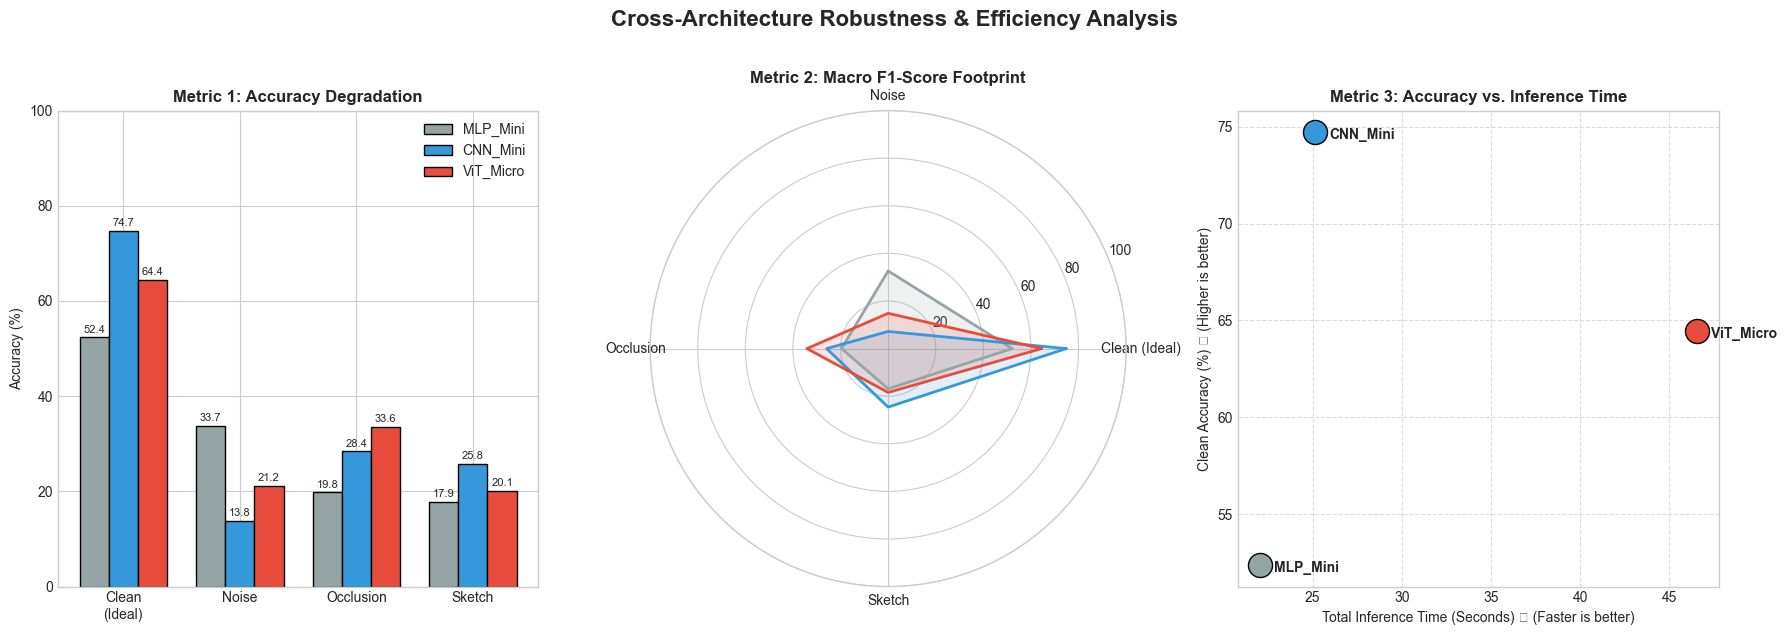

In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np

def run_visualization_phase(json_path='evaluation_results.json'):
    print(f"\n{'='*60}\n[Phase 3] Read JSON, generate multi-dimensional visualization report\n{'='*60}")
    
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            results = json.load(f)
    except FileNotFoundError:
        print(f"Cannot find {json_path}, please run the evaluation module first!")
        return

    scenarios = ['test_clean', 'test_noise', 'test_occlusion', 'test_sketch']
    labels_map = {'test_clean': 'Clean\n(Ideal)', 'test_noise': 'Noise', 'test_occlusion': 'Occlusion', 'test_sketch': 'Sketch'}
    model_names = list(results.keys())
    colors = ['#95a5a6', '#3498db', '#e74c3c'] 

    plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(18, 6))

    # ==========================================
    # Figure 1: Accuracy Bar Chart
    # ==========================================
    ax1 = plt.subplot(1, 3, 1)
    x = np.arange(len(scenarios))
    width = 0.25 
    
    for i, m in enumerate(model_names):
        accs = [results[m][sc]['acc'] for sc in scenarios]
        offset = (i - len(model_names)/2 + 0.5) * width
        rects = ax1.bar(x + offset, accs, width, label=m, color=colors[i], edgecolor='black')
        
        for rect in rects:
            height = rect.get_height()
            ax1.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width()/2, height),
                         xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=8)

    ax1.set_title('Metric 1: Accuracy Degradation', fontweight='bold')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([labels_map[sc] for sc in scenarios])
    ax1.legend()
    ax1.set_ylim(0, 100)

    # ==========================================
    # Figure 2: F1-Score Radar Chart
    # ==========================================
    ax2 = plt.subplot(1, 3, 2, polar=True)
    angles = np.linspace(0, 2 * np.pi, len(scenarios), endpoint=False).tolist()
    angles += angles[:1] 

    for i, m in enumerate(model_names):
        f1_scores = [results[m][sc]['f1'] for sc in scenarios]
        f1_scores += f1_scores[:1] 
        ax2.plot(angles, f1_scores, color=colors[i], linewidth=2, label=m)
        ax2.fill(angles, f1_scores, color=colors[i], alpha=0.15)

    ax2.set_title('Metric 2: Macro F1-Score Footprint', fontweight='bold', pad=20)
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels([labels_map[sc].replace('\n', ' ') for sc in scenarios])
    ax2.set_ylim(0, 100)

    # ==========================================
    # Figure 3: Efficiency Scatter
    # ==========================================
    ax3 = plt.subplot(1, 3, 3)
    for i, m in enumerate(model_names):
        clean_acc = results[m]['test_clean']['acc']

        total_time = sum([results[m][sc]['time'] for sc in scenarios])
        
        ax3.scatter(total_time, clean_acc, s=300, color=colors[i], edgecolor='black', label=m, zorder=5)
        ax3.annotate(m, (total_time, clean_acc), xytext=(10, -5), textcoords='offset points', fontweight='bold')

    ax3.set_title('Metric 3: Accuracy vs. Inference Time', fontweight='bold')
    ax3.set_xlabel('Total Inference Time (Seconds) ↘ (Faster is better)')
    ax3.set_ylabel('Clean Accuracy (%) ↖ (Higher is better)')
    ax3.grid(True, linestyle='--', alpha=0.7)

    plt.suptitle('Cross-Architecture Robustness & Efficiency Analysis', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('comprehensive_robustness_analysis.png', dpi=300, bbox_inches='tight')
    print("Visualization complete! Generated a comprehensive composite image with three dimensions: 'comprehensive_robustness_analysis.png'")
    plt.show()

if __name__ == "__main__":
    run_visualization_phase('evaluation_results.json')


[Phase 4] Generate 4x4 multi-scenario XAI feature heatmap matrix

4x4 full XAI image generated, saved as 'xai_saliency_all_scenarios.png'


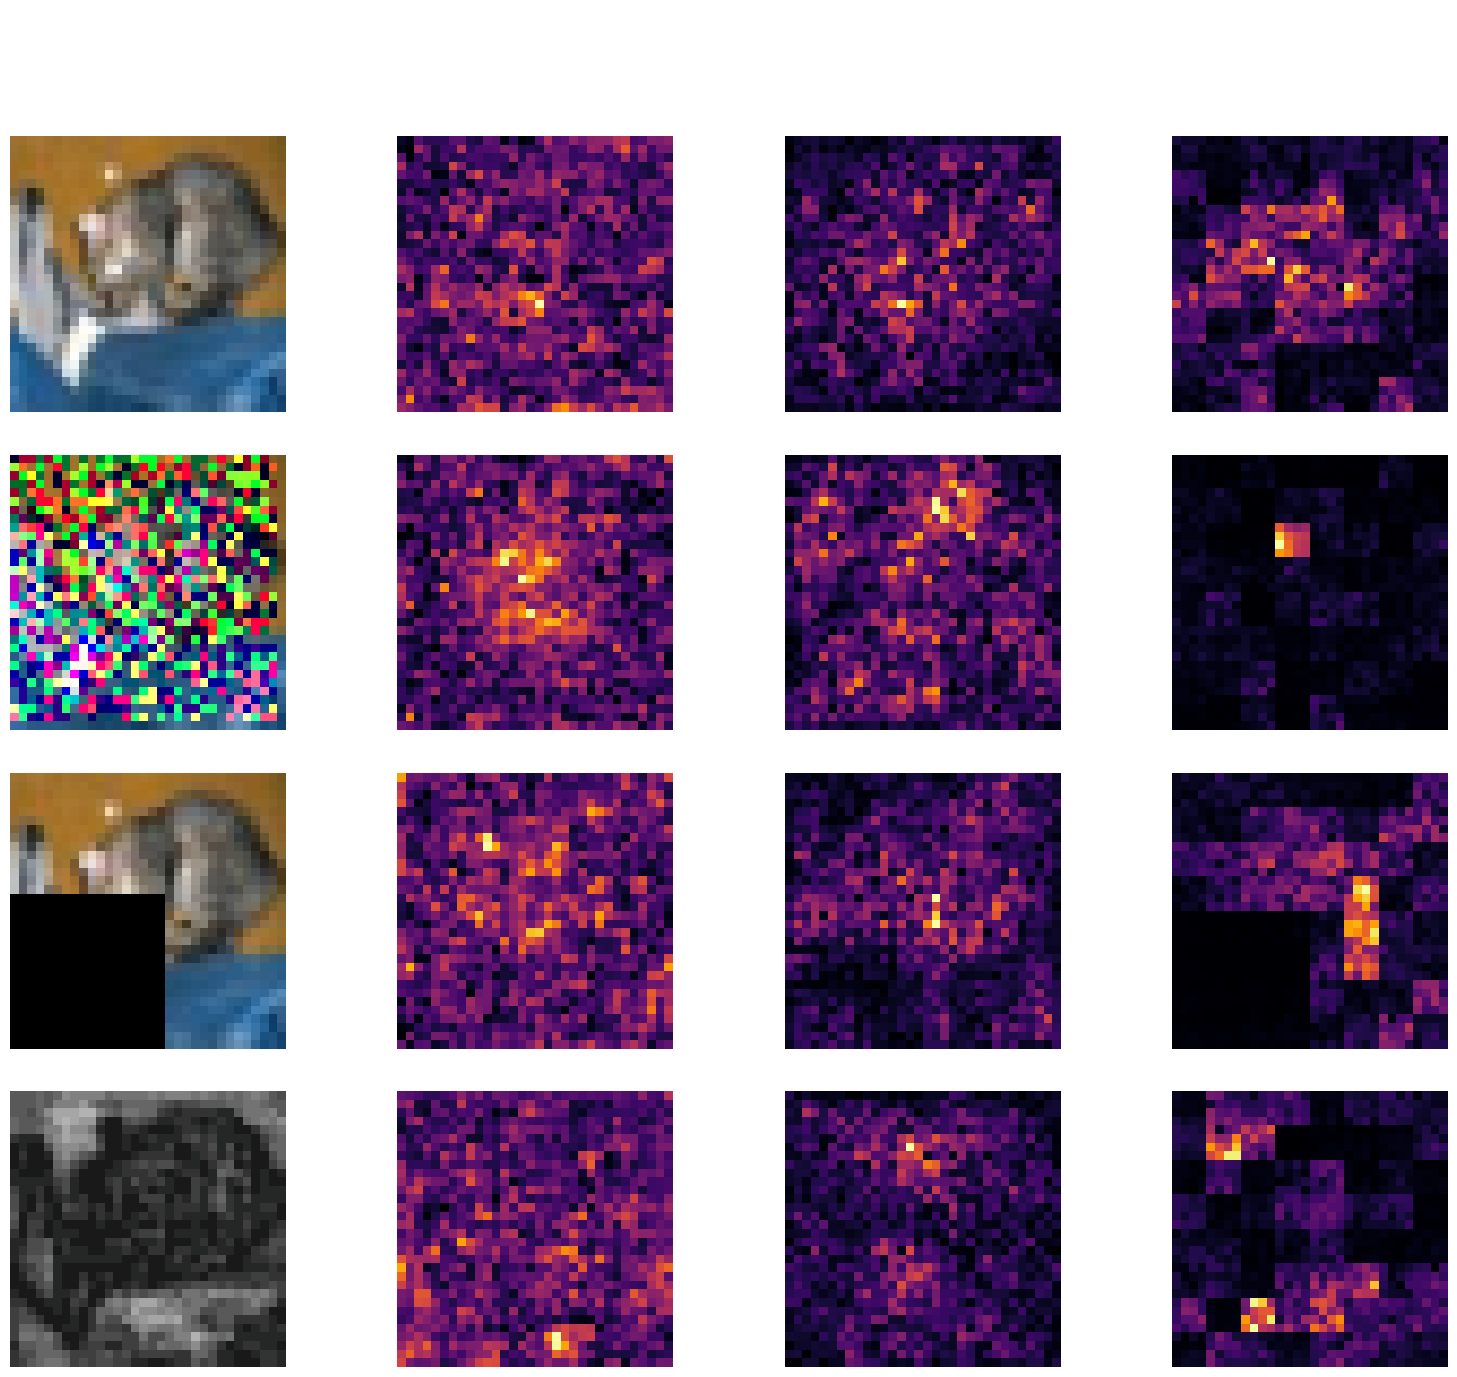

In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'Heiti TC'] 
plt.rcParams['axes.unicode_minus'] = False 

def get_saliency_map(model, image_tensor, target_class):
    model.eval()
    image_tensor = image_tensor.clone().requires_grad_()
    
    output = model(image_tensor)
    score = output[0, target_class]
    
    model.zero_grad()
    score.backward()
    
    saliency = image_tensor.grad.abs().squeeze().cpu()
    saliency, _ = torch.max(saliency, dim=0)
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency.numpy()

def visualize_all_scenarios_attention(models_dict, dataloaders, image_idx=0, device='cpu', weights_dir='./saved_models'):
    print(f"\n{'='*60}\n[Phase 4] Generate 4x4 multi-scenario XAI feature heatmap matrix\n{'='*60}")
    
    scenarios = ['test_clean', 'test_noise', 'test_occlusion', 'test_sketch']
    row_titles = ['Clean', 'Noisy (S&P)', 'Occlusion', 'Sketch']
    model_names = list(models_dict.keys())
    base_path = Path(weights_dir)
    
    loaded_models = {}
    for name, model in models_dict.items():
        safe_name = name.replace(" ", "_").lower()
        weight_path = base_path / f"{safe_name}_weights.pth"
        if weight_path.exists():
            model.load_state_dict(torch.load(weight_path, map_location=device))
        loaded_models[name] = model.to(device)

    fig, axes = plt.subplots(4, len(model_names) + 1, figsize=(16, 14))
    plt.style.use('dark_background') 
    
    def plot_image(ax, img_tensor, title):
        img_np = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        mean, std = np.array([0.4914, 0.4822, 0.4465]), np.array([0.2023, 0.1994, 0.2010])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        ax.set_title(title, fontsize=14, fontweight='bold', color='white', pad=10)
        ax.axis('off')

    def plot_heatmap(ax, saliency, title):
        ax.imshow(saliency, cmap='inferno')
        ax.set_title(title, fontsize=14, color='white', pad=10)
        ax.axis('off')

    for row_idx, (scen, r_title) in enumerate(zip(scenarios, row_titles)):
        img_tensor, target_class = dataloaders[scen].dataset[image_idx]
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        plot_image(axes[row_idx, 0], img_tensor, f"Input: {r_title}")
        
        for col_idx, name in enumerate(model_names):
            model = loaded_models[name]
            saliency = get_saliency_map(model, img_tensor, target_class)
            title = f"{name}" if row_idx == 0 else ""
            plot_heatmap(axes[row_idx, col_idx + 1], saliency, title)

    plt.suptitle("Comprehensive Saliency Map Comparison Across All Corruption Scenarios", fontsize=20, fontweight='bold', color='white', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    save_path = 'xai_saliency_all_scenarios.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f"\n4x4 full XAI image generated, saved as '{save_path}'")
    plt.show()

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    
    models_to_test = {
         "MLP_Mini": MLPMini(),
         "CNN_Mini": CNNMini(),
         "ViT_Micro": get_micro_vit_model() 
    }
    
    try:
        target_image_idx = 0 
        
        visualize_all_scenarios_attention(models_to_test, dataloaders, image_idx=target_image_idx, device=device)
    except NameError:
        print("Please ensure you have loaded dataloaders before running this code.")